# 2. nedēļa: Datu sagatavošana

## 1. uzdevums.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
df = pd.read_csv(url)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")

Rindu skaits: 12330
Kolonnu skaits: 18


In [4]:
# Datu tipi un trūkstošās vērtības
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
# Skaitlisko kolonnu statistika
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [6]:
# Trūkstošo vērtību skaits pa kolonnām
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
# Target mainīgā sadalījums
print(df['Revenue'].value_counts())
print(f"\nPirkumu veikušo sesiju īpatsvars: {df['Revenue'].mean():.1%}")

Revenue
False    10422
True      1908
Name: count, dtype: int64

Pirkumu veikušo sesiju īpatsvars: 15.5%


### 1.3. Datu apraksts
- Izmērs - 12 330 rindas, 18 kolonnas
- Kolonnu tipi - 14 skaitliskas, 4 kategoriskas
- Trūkstošās vērtības - nav nevienas nevienā kolonnā
- Pirkumu īpatsvars - 15.5% sesiju beidzās ar pirkumu

## 2. uzdevums.

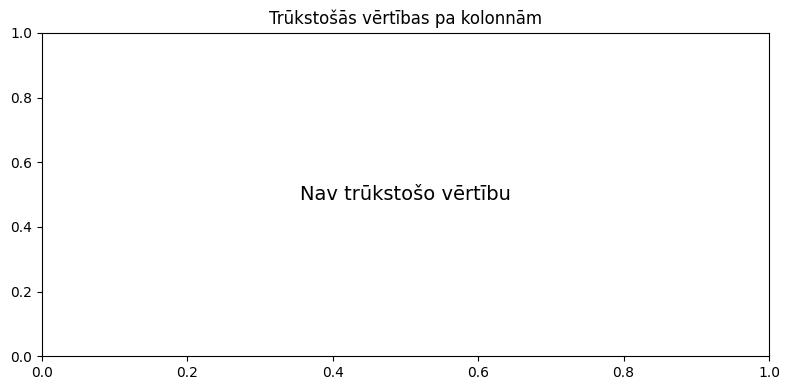

✓ Visas trūkstošās vērtības ir apstrādātas.


In [8]:
# Trūkstošo vērtību vizualizācija
missing = df.isnull().sum()
missing_filtered = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
if len(missing_filtered) > 0:
    missing_filtered.plot(kind='bar', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.ylabel('Skaits')
else:
    plt.text(0.5, 0.5, 'Nav trūkstošo vērtību', ha='center', va='center', fontsize=14)
    plt.title('Trūkstošās vērtības pa kolonnām')
plt.tight_layout()
plt.show()

# Pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("✓ Visas trūkstošās vērtības ir apstrādātas.")

### 2.2. Trūkstošo vērtību apstrāde

Datu kopā nav trūkstošo vērtību — visas 18 kolonnas ir pilnīgas. Papildu aizpildīšana nav nepieciešama.

## 3. uzdevums.

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

In [10]:
# Pirms normalizācijas — parādi statistiku
print("PIRMS normalizācijas:")
print(df[numeric_cols].describe().round(2))

PIRMS normalizācijas:
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count                12330.00        12330.00                 12330.00   
mean                    34.47           31.73                  1194.75   
std                    140.75           44.48                  1913.67   
min                      0.00            0.00                     0.00   
25%                   

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_old = df.copy()  # Saglabājam kopiju pirms normalizācijas
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\nPĒC normalizācijas:")
print(df[numeric_cols].describe().round(2))


PĒC normalizācijas:
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count                12330.00        12330.00                 12330.00   
mean                    -0.00            0.00                    -0.00   
std                      1.00            1.00                     1.00   
min                     -0.24           -0.71                    -0.62   
25%                    

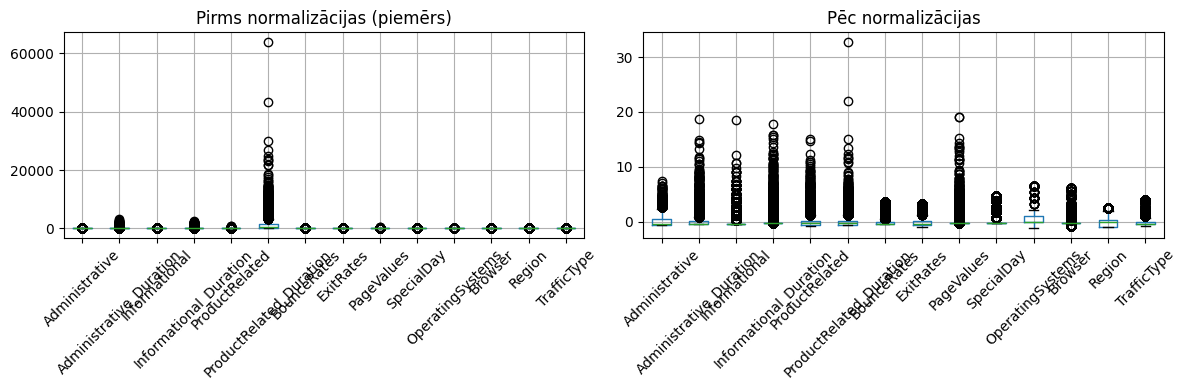

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 
# Pirms (parādīsim uz vienas kolonnas piemēru) 
df_old[numeric_cols].boxplot(ax=axes[0])
axes[0].set_title('Pirms normalizācijas (piemērs)') 
axes[0].tick_params(axis='x', rotation=45) 

df[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('Pēc normalizācijas')
axes[1].tick_params(axis='x', rotation=45) 
plt.tight_layout() 

plt.show()

## 4. uzdevums

In [13]:
# Kuras kolonnas ir kategoriskas? 
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist() 
print("Kategoriskās kolonnas:", cat_cols)

for col in cat_cols: 
    print(f"\n{col}: {df[col].unique()}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: [False  True]

Revenue: [False  True]


C:\Users\Ilya\AppData\Local\Temp\ipykernel_35784\2551967907.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [14]:
from sklearn.preprocessing import LabelEncoder
# Boolean kolonnas — pārvērš uz 0/1 
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int) 

# One-Hot Encoding kategoriskām kolonnām 
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Pārvērš OHE kolonnas no bool uz 0/1, lai nepaliek kategoriskie tipi
ohe_cols = [c for c in df.columns if c.startswith('Month_') or c.startswith('VisitorType_')]
df[ohe_cols] = df[ohe_cols].astype(int)

print(f"Kolonnu skaits pēc kodēšanas: {df.shape[1]}")
df.head()

Kolonnu skaits pēc kodēšanas: 27


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,1,0,0,0,0,0,0,0,0,1
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,1,0,0,0,0,0,0,0,0,1
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,1,0,0,0,0,0,0,0,0,1
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,1,0,0,0,0,0,0,0,0,1
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,1,0,0,0,0,0,0,0,0,1


### 4.2. Kodēšanas metodes pamatojums

- **Weekend, Revenue** -> `astype(int)`: binārās (True/False) kolonnas → 0/1
- **Month** -> One-Hot (drop_first=True): 10 mēneši bez dabiskas ordinalitātes
- **VisitorType** -> One-Hot (drop_first=True): 3 kategorijas bez rangu hierarhijas

In [15]:
# Pārliecinies, ka nav palikušas kategorisko tipa kolonnas
remaining_objects = df.select_dtypes(include=['object', 'bool', 'string']).columns.tolist()
print(f"Atlikušās kategoriskās kolonnas: {remaining_objects}")
assert len(remaining_objects) == 0, "Vēl ir neapstrādātas kategoriskas kolonnas!"
print("✓ Visas kategoriskās kolonnas ir kodētas.")
print(f"Kolonnu skaits pēc kodēšanas: {df.shape[1]}")

Atlikušās kategoriskās kolonnas: []
✓ Visas kategoriskās kolonnas ir kodētas.
Kolonnu skaits pēc kodēšanas: 27


## 5. uzdevums. Jauna iezīme (Feature Engineering)

In [16]:
# Kopējais laiks vietnē (normalizēto vērtību summa)
df['TotalDuration'] = (df['Administrative_Duration'] +
                       df['Informational_Duration'] +
                       df['ProductRelated_Duration'])

print(f"Jaunā kolonna 'TotalDuration' pievienota.")
print(df['TotalDuration'].describe().round(3))

Jaunā kolonna 'TotalDuration' pievienota.
count    12330.000
mean        -0.000
std          2.210
min         -1.326
25%         -1.164
50%         -0.703
75%          0.260
max         69.445
Name: TotalDuration, dtype: float64


### 5.2. Jaunās iezīmes pamatojums

**TotalDuration** - kopējais laiks, ko lietotājs pavadīja vietnē (administratīvās, informatīvās un produktu lapas kopā).

- **Biznesa nozīme**: lietotāji, kas pavada vairāk laika, ir iesaistītāki un biežāk veic pirkumus.
- **ML vērtība**: apkopo trīs korelētas kolonnas vienā - samazina dimensiju un uztver kopējo iesaisti.

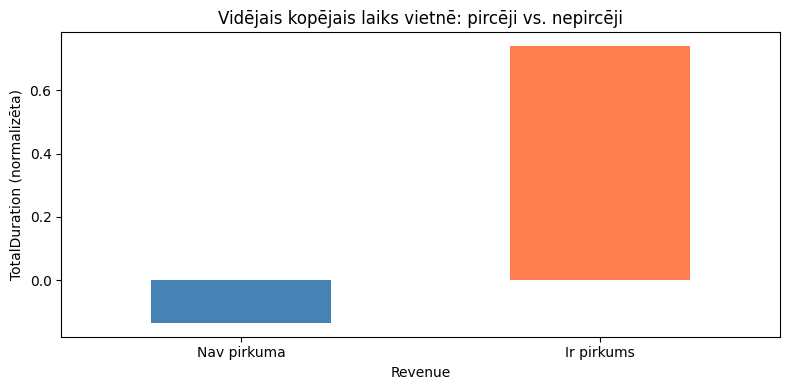

In [17]:
# Vizualizē TotalDuration: pircēji vs. nepircēji
plt.figure(figsize=(8, 4))
df.groupby('Revenue')['TotalDuration'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Vidējais kopējais laiks vietnē: pircēji vs. nepircēji')
plt.ylabel('TotalDuration (normalizēta)')
plt.xticks([0, 1], ['Nav pirkuma', 'Ir pirkums'], rotation=0)
plt.tight_layout()
plt.show()

## 6. uzdevums. Saglabā tīru datu kopu

In [18]:
# Saglabā tīro dataset nākamajai nedēļai
df.to_csv('shoppers_clean.csv', index=False)
print(f"Saglabāts: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print("✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'")

Saglabāts: 12330 rindas, 28 kolonnas
✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'


### 6.2. Rezumējums

**Atklātās problēmas:** nav trūkstošo vērtību; kategoriskas kolonnas (Month, VisitorType, Weekend, Revenue) nav gatavas ML modelim.

**Veiktās darbības:**
1. Skaitliskās kolonnas normalizētas ar StandardScaler (vidējais ≈ 0, std ≈ 1)
2. Boolean kolonnas pārvērstas uz 0/1; Month un VisitorType - One-Hot Encoding
3. Izveidota jauna iezīme `TotalDuration`

**Struktūras izmaiņas:** 18 -> 28 kolonnas (9 no Month OHE, 2 no VisitorType OHE, +1 TotalDuration, −2 oriģinālās kategoriskās)